# DATA 620 - Week 3 Assignment

**Andre Thomson**

For this assignment, I used the Zachary Karate Club network. I saved the graph as a text edge file and loaded it into Python with NetworkX.

I used the graph to look at the adjacency matrix, diameter, degree centrality, and density. I also created a graph so I could see the network.


## Import packages

I used NetworkX for the graph, pandas for the adjacency matrix, and matplotlib to draw it.


In [1]:
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt


## Load the data

The data is in a text file. Each line has two node numbers. Those two numbers mean the nodes are connected.


In [2]:
data_path = Path("data/karate_club_edges.txt")
G = nx.read_edgelist(data_path, nodetype=int)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected:", nx.is_connected(G))


Nodes: 34
Edges: 78
Connected: True


## Adjacency matrix

I created an adjacency matrix to see the connections another way. A 1 means there is a connection and a 0 means there is not.

The full matrix is 34 by 34, so I only displayed the first 10 rows and columns.


In [3]:
node_order = sorted(G.nodes())
adjacency = nx.to_pandas_adjacency(G, nodelist=node_order, dtype=int)
print("Adjacency matrix shape:", adjacency.shape)
adjacency.iloc[:10, :10]


Adjacency matrix shape: (34, 34)


,0,1,2,3,4,5,6,7,8,9
0,0,1,1,1,1,1,1,1,1,0
1,1,0,1,1,0,0,0,1,0,0
2,1,1,0,1,0,0,0,1,1,1
3,1,1,1,0,0,0,0,1,0,0
4,1,0,0,0,0,0,1,0,0,0
5,1,0,0,0,0,0,1,0,0,0
6,1,0,0,0,1,1,0,0,0,0
7,1,1,1,1,0,0,0,0,0,0
8,1,0,1,0,0,0,0,0,0,0
9,0,0,1,0,0,0,0,0,0,0


## Diameter

Next I calculated the diameter. Before doing that, I checked if the graph was connected.

The diameter tells me the longest shortest path between two nodes in the network.


In [4]:
if nx.is_connected(G):
    diameter = nx.diameter(G)
    print("Graph diameter:", diameter)
else:
    print("The graph is disconnected, so diameter is not calculated for the full graph.")


Graph diameter: 5


## Degree centrality

For the second metric, I used degree centrality. I chose this because I wanted to see which nodes had the most direct connections.

I printed the top five instead of showing every node.


In [5]:
degree_centrality = nx.degree_centrality(G)
top_five = sorted(
    degree_centrality.items(),
    key=lambda item: item[1],
    reverse=True
)[:5]

for node, value in top_five:
    print(f"Node {node}: {value:.3f}")


Node 33: 0.515
Node 0: 0.485
Node 32: 0.364
Node 2: 0.303
Node 1: 0.273


## Density

I also checked the density. This gives me an idea of how connected the whole network is compared with all the connections that could have existed.


In [6]:
density = nx.density(G)
print(f"Graph density: {density:.3f}")


Graph density: 0.139


## Graph

I used a spring layout to draw the network. I used degree centrality for the node colors so I could see which nodes have more direct connections. The color bar shows what the colors mean.

I kept the seed at 42 so the graph stays in the same position when I run it again.


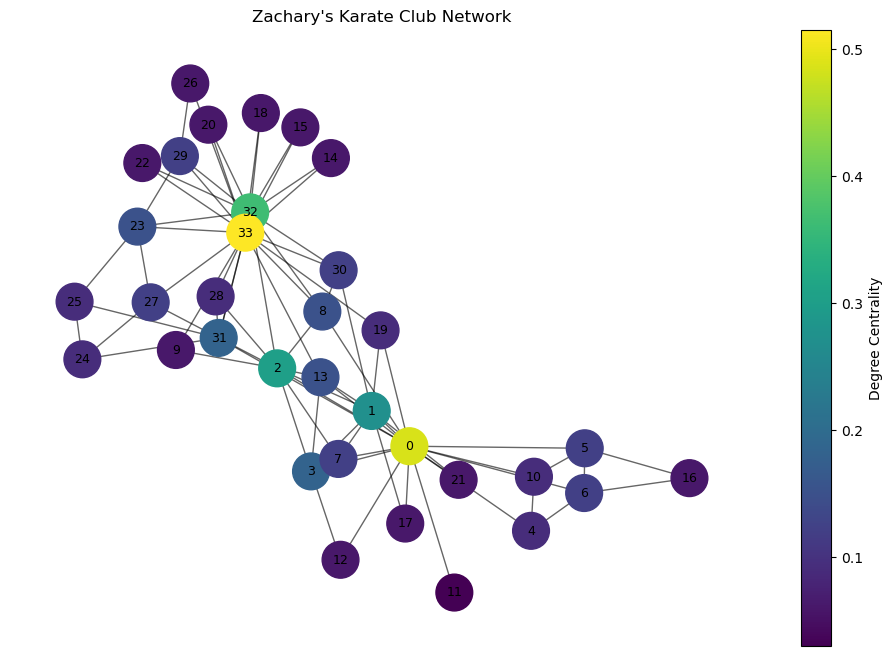

In [7]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

# Use degree centrality for the node colors
degree_centrality = nx.degree_centrality(G)
node_colors = [degree_centrality[node] for node in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    node_size=700
)

nx.draw_networkx_edges(
    G,
    pos,
    width=1.0,
    alpha=0.6
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

plt.colorbar(nodes, label="Degree Centrality")
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()


## What I found

The graph has **34 nodes** and **78 edges**. It is connected.

The diameter is **5**. This means the longest shortest path between two nodes is 5 edges.

Nodes **33** and **0** had the highest degree centrality, so they have the most direct connections in this graph. The density was about **0.139**.

Looking at the graph also helped me see that some nodes have a lot more connections than others.


## References

- Tsvetovat, M. and Kouznetsov, A. *Social Network Analysis for Startups*, Chapter 2. Course reading.
- Zachary, W. W. (1977). *An Information Flow Model for Conflict and Fission in Small Groups*.
- NetworkX documentation: https://networkx.org/documentation/stable/
- Robinson, I., Webber, J., and Eifrem, E. *Graph Databases*, 2nd ed. Optional course reading.

## AI use

I used AI to help check the assignment requirements, review my code, and help me understand errors. I ran the code and checked the results before using them.
